## Data Preprocessing 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import missingno as msno


In [2]:
electricity_access_df = pd.read_csv("data/raw/1.AccessToElectricityAPI_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63.csv", skiprows=4)
gdp_df = pd.read_csv("data/raw/2.GDPAPI_NY.GDP.PCAP.CD_DS2_en_csv_v2_31/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv", skiprows=4)
urban_population_df = pd.read_csv("data/raw/3.UrbanAPI_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608.csv", skiprows=4)
rural_population_df = pd.read_csv("data/raw/4.RuralAPI_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502/API_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502.csv", skiprows=4)
population_density_df = pd.read_csv("data/raw/5.PopulationDensityAPI_EN.POP.DNST_DS2_en_csv_v2_275/API_EN.POP.DNST_DS2_en_csv_v2_275.csv", skiprows=4)
total_population_df = pd.read_csv("data/raw/6.TotalPopulationAPI_SP.POP.TOTL_DS2_en_csv_v2_7/API_SP.POP.TOTL_DS2_en_csv_v2_7.csv", skiprows=4)
renewable_energy_df = pd.read_csv("data/raw/7.RenewableEnergyAPI_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409.csv", skiprows=4)
government_effectiveness_df = pd.read_csv("data/raw/8.GovernmentEffectivenessAPI_GE.EST_DS2_en_csv_v2_2683/API_GE.EST_DS2_en_csv_v2_2683.csv", skiprows=4)


In [3]:
# Drop unwanted "Unnamed" columns
electricity_access_df = electricity_access_df.loc[:, ~electricity_access_df.columns.str.contains("Unnamed")]
gdp_df = gdp_df.loc[:, ~gdp_df.columns.str.contains("Unnamed")]
urban_population_df = urban_population_df.loc[:, ~urban_population_df.columns.str.contains("Unnamed")]
rural_population_df = rural_population_df.loc[:, ~rural_population_df.columns.str.contains("Unnamed")]
population_density_df = population_density_df.loc[:, ~population_density_df.columns.str.contains("Unnamed")]
total_population_df = total_population_df.loc[:, ~total_population_df.columns.str.contains("Unnamed")]
renewable_energy_df = renewable_energy_df.loc[:, ~renewable_energy_df.columns.str.contains("Unnamed")]
government_effectiveness_df = government_effectiveness_df.loc[:, ~government_effectiveness_df.columns.str.contains("Unnamed")]

In [4]:
# Identify and remove non-country entries
non_countries = [
    "World", "High income", "Low income", "Middle income", "Lower middle income", "Upper middle income",
    "Low & middle income", "Early-demographic dividend", "Late-demographic dividend", "Post-demographic dividend",
    "Pre-demographic dividend", "Europe & Central Asia", "Sub-Saharan Africa", "Latin America & Caribbean",
    "Arab World", "North America", "South Asia", "OECD members", "Small states", "Other small states",
    "Pacific island small states", "Euro area", "European Union", "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)", "IBRD only", "IDA total", "IDA & IBRD total", "IDA blend", "IDA only",
    "East Asia & Pacific", "East Asia & Pacific (IDA & IBRD countries)", "East Asia & Pacific (excluding high income)",
    "Europe & Central Asia (IDA & IBRD countries)", "Europe & Central Asia (excluding high income)",
    "Latin America & Caribbean (excluding high income)", "Latin America & the Caribbean (IDA & IBRD countries)",
    "Middle East, North Africa, Afghanistan & Pakistan", 
    "Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)",
    "Middle East, North Africa, Afghanistan & Pakistan (excluding high income)",
    "Sub-Saharan Africa (IDA & IBRD countries)", "Sub-Saharan Africa (excluding high income)",
    "Africa Eastern and Southern", "Africa Western and Central", "Caribbean small states", 
    "Central Europe and the Baltics"
]

# Filter out non-country entries from each dataset
electricity_access_df = electricity_access_df[~electricity_access_df["Country Name"].isin(non_countries)]
gdp_df = gdp_df[~gdp_df["Country Name"].isin(non_countries)]
urban_population_df = urban_population_df[~urban_population_df["Country Name"].isin(non_countries)]
rural_population_df = rural_population_df[~rural_population_df["Country Name"].isin(non_countries)]
population_density_df = population_density_df[~population_density_df["Country Name"].isin(non_countries)]
total_population_df = total_population_df[~total_population_df["Country Name"].isin(non_countries)]
renewable_energy_df = renewable_energy_df[~renewable_energy_df["Country Name"].isin(non_countries)]
government_effectiveness_df = government_effectiveness_df[~government_effectiveness_df["Country Name"].isin(non_countries)]

In [5]:
# Inspect columns
print(electricity_access_df.columns)
print(gdp_df.columns)
print(urban_population_df.columns)
print(rural_population_df.columns)
print(population_density_df.columns)
print(total_population_df.columns)
print(renewable_energy_df.columns)
print(government_effectiveness_df.columns)

# Keep only necessary columns: Country Name, Country Code, and all years (1960 onwards)
# Drop Indicator Name and Indicator Code
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in electricity_access_df.columns if col.isdigit()]
electricity_access_df = electricity_access_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in urban_population_df.columns if col.isdigit()]
urban_population_df = urban_population_df[cols_to_keep]                     
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in rural_population_df.columns if col.isdigit()]
rural_population_df = rural_population_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in population_density_df.columns if col.isdigit()]
population_density_df = population_density_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in total_population_df.columns if col.isdigit()]
total_population_df = total_population_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in renewable_energy_df.columns if col.isdigit()]
renewable_energy_df = renewable_energy_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in government_effectiveness_df.columns if col.isdigit()]
government_effectiveness_df = government_effectiveness_df[cols_to_keep] 

# Rename columns for convenience
electricity_access_df.columns = electricity_access_df.columns.str.strip()
electricity_access_df = electricity_access_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
gdp_df.columns = gdp_df.columns.str.strip()
gdp_df = gdp_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
urban_population_df.columns = urban_population_df.columns.str.strip()
urban_population_df = urban_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
rural_population_df.columns = rural_population_df.columns.str.strip()
rural_population_df = rural_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
population_density_df.columns = population_density_df.columns.str.strip()
population_density_df = population_density_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
total_population_df.columns = total_population_df.columns.str.strip()
total_population_df = total_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
renewable_energy_df.columns = renewable_energy_df.columns.str.strip()
renewable_energy_df = renewable_energy_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
government_effectiveness_df.columns = government_effectiveness_df.columns.str.strip()
government_effectiveness_df = government_effectiveness_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})   


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='str')
Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1

In [6]:
# Reshape electricity access dataset from wide to long format
electricity_access_df_long = electricity_access_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="electricity_access"
)
gdp_df_long = gdp_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="gdp_per_capita"
)
urban_population_df_long = urban_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],  
    var_name="year",
    value_name="urban_population_percent"
)
rural_population_df_long = rural_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="rural_population_percent"
)
population_density_df_long = population_density_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="population_density"
)
total_population_df_long = total_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="total_population"
)
renewable_energy_df_long = renewable_energy_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],  
    var_name="year",
    value_name="renewable_energy_percent"
)
government_effectiveness_df_long = government_effectiveness_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="government_effectiveness"
)
# Convert year column to integer
electricity_access_df_long["year"] = electricity_access_df_long["year"].astype(int)
gdp_df_long["year"] = gdp_df_long["year"].astype(int)
urban_population_df_long["year"] = urban_population_df_long["year"].astype(int)
rural_population_df_long["year"] = rural_population_df_long["year"].astype(int)
population_density_df_long["year"] = population_density_df_long["year"].astype(int)
total_population_df_long["year"] = total_population_df_long["year"].astype(int)
renewable_energy_df_long["year"] = renewable_energy_df_long["year"].astype(int)
government_effectiveness_df_long["year"] = government_effectiveness_df_long["year"].astype(int)

# Convert electricity_access to numeric (some cells might be empty strings)
electricity_access_df_long['electricity_access'] = pd.to_numeric(electricity_access_df_long['electricity_access'], errors='coerce')
gdp_df_long['gdp_per_capita'] = pd.to_numeric(gdp_df_long['gdp_per_capita'], errors='coerce')
urban_population_df_long['urban_population_percent'] = pd.to_numeric(urban_population_df_long['urban_population_percent'], errors='coerce')
rural_population_df_long['rural_population_percent'] = pd.to_numeric(rural_population_df_long['rural_population_percent'], errors='coerce')     
population_density_df_long['population_density'] = pd.to_numeric(population_density_df_long['population_density'], errors='coerce')
total_population_df_long['total_population'] = pd.to_numeric(total_population_df_long['total_population'], errors='coerce')
renewable_energy_df_long['renewable_energy_percent'] = pd.to_numeric(renewable_energy_df_long['renewable_energy_percent'], errors='coerce')
government_effectiveness_df_long['government_effectiveness'] = pd.to_numeric(government_effectiveness_df_long['government_effectiveness'], errors='coerce')


# Sort by country and year
electricity_access_df_long = electricity_access_df_long.sort_values(['country', 'year']).reset_index(drop=True)
gdp_df_long = gdp_df_long.sort_values(['country', 'year']).reset_index(drop=True)
urban_population_df_long = urban_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
rural_population_df_long = rural_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
population_density_df_long = population_density_df_long.sort_values(['country', 'year']).reset_index(drop=True)
total_population_df_long = total_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
renewable_energy_df_long = renewable_energy_df_long.sort_values(['country', 'year']).reset_index(drop=True)
government_effectiveness_df_long = government_effectiveness_df_long.sort_values(['country', 'year']).reset_index(drop=True)


In [7]:
# Keep only 1990 and later
electricity_access_df_long = electricity_access_df_long[electricity_access_df_long['year'] >= 1990].reset_index(drop=True)
gdp_df_long = gdp_df_long[gdp_df_long['year'] >= 1990].reset_index(drop=True)
urban_population_df_long = urban_population_df_long[urban_population_df_long['year'] >= 1990].reset_index(drop=True)
rural_population_df_long = rural_population_df_long[rural_population_df_long['year'] >= 1990].reset_index(drop=True)
population_density_df_long = population_density_df_long[population_density_df_long['year'] >= 1990].reset_index(drop=True)
total_population_df_long = total_population_df_long[total_population_df_long['year'] >= 1990].reset_index(drop=True)
renewable_energy_df_long = renewable_energy_df_long[renewable_energy_df_long['year'] >= 1990].reset_index(drop=True)
government_effectiveness_df_long = government_effectiveness_df_long[government_effectiveness_df_long['year'] >= 1990].reset_index(drop=True)


In [8]:

print(electricity_access_df_long.head(10))
print(gdp_df_long.head(10))
print(urban_population_df_long.head(10))
print(rural_population_df_long.head(10))
print(population_density_df_long.head(10))
print(total_population_df_long.head(10))
print(renewable_energy_df_long.head(10))
print(government_effectiveness_df_long.head(10))


       country country_code  year  electricity_access
0  Afghanistan          AFG  1990                 NaN
1  Afghanistan          AFG  1991                 NaN
2  Afghanistan          AFG  1992                 NaN
3  Afghanistan          AFG  1993                 NaN
4  Afghanistan          AFG  1994                 NaN
5  Afghanistan          AFG  1995                 NaN
6  Afghanistan          AFG  1996                 NaN
7  Afghanistan          AFG  1997                 NaN
8  Afghanistan          AFG  1998                 NaN
9  Afghanistan          AFG  1999                 NaN
       country country_code  year  gdp_per_capita
0  Afghanistan          AFG  1990             NaN
1  Afghanistan          AFG  1991             NaN
2  Afghanistan          AFG  1992             NaN
3  Afghanistan          AFG  1993             NaN
4  Afghanistan          AFG  1994             NaN
5  Afghanistan          AFG  1995             NaN
6  Afghanistan          AFG  1996             NaN
7  Afg

In [9]:
# Electricity access
electricity_access_df_long = electricity_access_df_long.sort_values(['country', 'year'])
electricity_access_df_long['electricity_access'] = (
    electricity_access_df_long.groupby('country')['electricity_access']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# GDP per capita
gdp_df_long = gdp_df_long.sort_values(['country', 'year'])
gdp_df_long['gdp_per_capita'] = (
    gdp_df_long.groupby('country')['gdp_per_capita']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Urban population
urban_population_df_long = urban_population_df_long.sort_values(['country', 'year'])
urban_population_df_long['urban_population_percent'] = (
    urban_population_df_long.groupby('country')['urban_population_percent']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Rural population
rural_population_df_long = rural_population_df_long.sort_values(['country', 'year'])
rural_population_df_long['rural_population_percent'] = (
    rural_population_df_long.groupby('country')['rural_population_percent']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Population density
population_density_df_long = population_density_df_long.sort_values(['country', 'year'])
population_density_df_long['population_density'] = (
    population_density_df_long.groupby('country')['population_density']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Total population
total_population_df_long = total_population_df_long.sort_values(['country', 'year'])
total_population_df_long['total_population'] = (
    total_population_df_long.groupby('country')['total_population']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Renewable energy
renewable_energy_df_long = renewable_energy_df_long.sort_values(['country', 'year'])
renewable_energy_df_long['renewable_energy_percent'] = (
    renewable_energy_df_long.groupby('country')['renewable_energy_percent']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Government effectiveness
government_effectiveness_df_long = government_effectiveness_df_long.sort_values(['country', 'year'])
government_effectiveness_df_long['government_effectiveness'] = (
    government_effectiveness_df_long.groupby('country')['government_effectiveness']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

In [10]:
# Save cleaned and reshaped datasets to new CSV files for future use
electricity_access_df_long.to_csv("data/processed/electricity_access_long.csv", index=False)
gdp_df_long.to_csv("data/processed/gdp_long.csv", index=False)
urban_population_df_long.to_csv("data/processed/urban_population_long.csv", index=False)
rural_population_df_long.to_csv("data/processed/rural_population_long.csv", index=False)
population_density_df_long.to_csv("data/processed/population_density_long.csv", index=False)
total_population_df_long.to_csv("data/processed/total_population_long.csv", index=False)
renewable_energy_df_long.to_csv("data/processed/renewable_energy_long.csv", index=False)
government_effectiveness_df_long.to_csv("data/processed/government_effectiveness_long.csv", index=False)


In [11]:
# Merge all datasets into a single dataframe for modeling

merged_df = electricity_access_df_long[['country', 'country_code', 'year', 'electricity_access']]
merged_df = merged_df.merge(gdp_df_long[['country', 'year', 'gdp_per_capita']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(urban_population_df_long[['country', 'year', 'urban_population_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(rural_population_df_long[['country', 'year', 'rural_population_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(population_density_df_long[['country', 'year', 'population_density']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(total_population_df_long[['country', 'year', 'total_population']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(renewable_energy_df_long[['country', 'year', 'renewable_energy_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(government_effectiveness_df_long[['country', 'year', 'government_effectiveness']], on=['country', 'year'], how='left')

# Save the final merged dataset to a CSV file for modeling
merged_df.to_csv('data/processed/merged_dataset.csv', index=False)

In [12]:
# Load the merged dataset
df = pd.read_csv('data/processed/merged_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of countries: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

# Display first 10 rows
df.head(10)

Dataset shape: (7700, 11)
Number of countries: 220
Year range: 1990 to 2024


,country,country_code,year,electricity_access,gdp_per_capita,urban_population_percent,rural_population_percent,population_density,total_population,renewable_energy_percent,government_effectiveness
0,Afghanistan,AFG,1990,4.4,174.930991,17.264035,82.735965,18.468424,12045660.0,23.0,-2.175167
1,Afghanistan,AFG,1991,4.4,174.930991,17.376660,82.623340,18.764667,12238879.0,23.7,-2.175167
2,Afghanistan,AFG,1992,4.4,174.930991,17.488203,82.511797,20.359343,13278974.0,27.4,-2.175167
3,Afghanistan,AFG,1993,4.4,174.930991,17.600467,82.399533,22.910893,14943172.0,28.5,-2.175167
4,Afghanistan,AFG,1994,4.4,174.930991,17.715260,82.284740,24.915741,16250794.0,30.1,-2.175167
5,Afghanistan,AFG,1995,4.4,174.930991,17.834385,82.165615,26.165365,17065836.0,31.8,-2.175167
6,Afghanistan,AFG,1996,4.4,174.930991,17.959649,82.040351,27.234666,17763266.0,33.9,-2.175167
7,Afghanistan,AFG,1997,4.4,174.930991,18.092857,81.907143,28.290773,18452091.0,36.4,-2.138729
8,Afghanistan,AFG,1998,4.4,174.930991,18.235814,81.764186,29.376134,19159996.0,38.0,-2.102292
9,Afghanistan,AFG,1999,4.4,174.930991,18.390327,81.609673,30.491981,19887785.0,43.4,-2.138119


In [13]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   7700 non-null   str    
 1   country_code              7700 non-null   str    
 2   year                      7700 non-null   int64  
 3   electricity_access        7630 non-null   float64
 4   gdp_per_capita            7560 non-null   float64
 5   urban_population_percent  7665 non-null   float64
 6   rural_population_percent  7665 non-null   float64
 7   population_density        7630 non-null   float64
 8   total_population          7665 non-null   float64
 9   renewable_energy_percent  7490 non-null   float64
 10  government_effectiveness  7175 non-null   float64
dtypes: float64(8), int64(1), str(2)
memory usage: 661.8 KB


In [14]:
# Summary statistics
df.describe()

,year,electricity_access,gdp_per_capita,urban_population_percent,rural_population_percent,population_density,total_population,renewable_energy_percent,government_effectiveness
count,7700.000000,7630.000000,7560.000000,7665.000000,7665.000000,7630.000000,7.665000e+03,7490.00000,7175.000000
mean,2007.000000,78.855721,13884.361654,57.650085,42.349915,396.615678,4.070550e+07,30.81704,-0.019695
std,10.100161,31.110846,22815.472376,24.432049,24.432049,1840.294135,1.631854e+08,30.22664,0.991221
min,1990.000000,0.533899,22.952133,5.274941,0.000000,0.136436,8.798000e+03,0.00000,-2.440229
25%,1998.000000,62.725000,1165.665096,36.618503,22.686951,31.614967,6.672140e+05,3.80000,-0.736714
50%,2007.000000,98.700000,4158.504543,58.245076,41.754924,81.942149,5.467059e+06,20.15000,-0.166648
75%,2016.000000,100.000000,18313.414527,77.313049,63.381497,208.449671,2.013981e+07,52.90000,0.654168
max,2024.000000,100.000000,288001.433369,100.000000,94.725059,21530.000000,1.677385e+09,98.30000,2.469660


In [15]:
# Count missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_pct.round(2)
})

print("Missing Values Summary:")
missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

Missing Values Summary:


,Missing_Count,Missing_Percentage
government_effectiveness,525,6.82
renewable_energy_percent,210,2.73
gdp_per_capita,140,1.82
electricity_access,70,0.91
population_density,70,0.91
urban_population_percent,35,0.45
rural_population_percent,35,0.45
total_population,35,0.45


In [16]:
# Check for duplicate rows
duplicates = df.duplicated(subset=['country', 'year']).sum()
print(f"Duplicate country-year combinations: {duplicates}")

if duplicates > 0:
    print("\nShowing duplicate rows:")
    display(df[df.duplicated(subset=['country', 'year'], keep=False)].sort_values(['country', 'year']))

Duplicate country-year combinations: 0


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


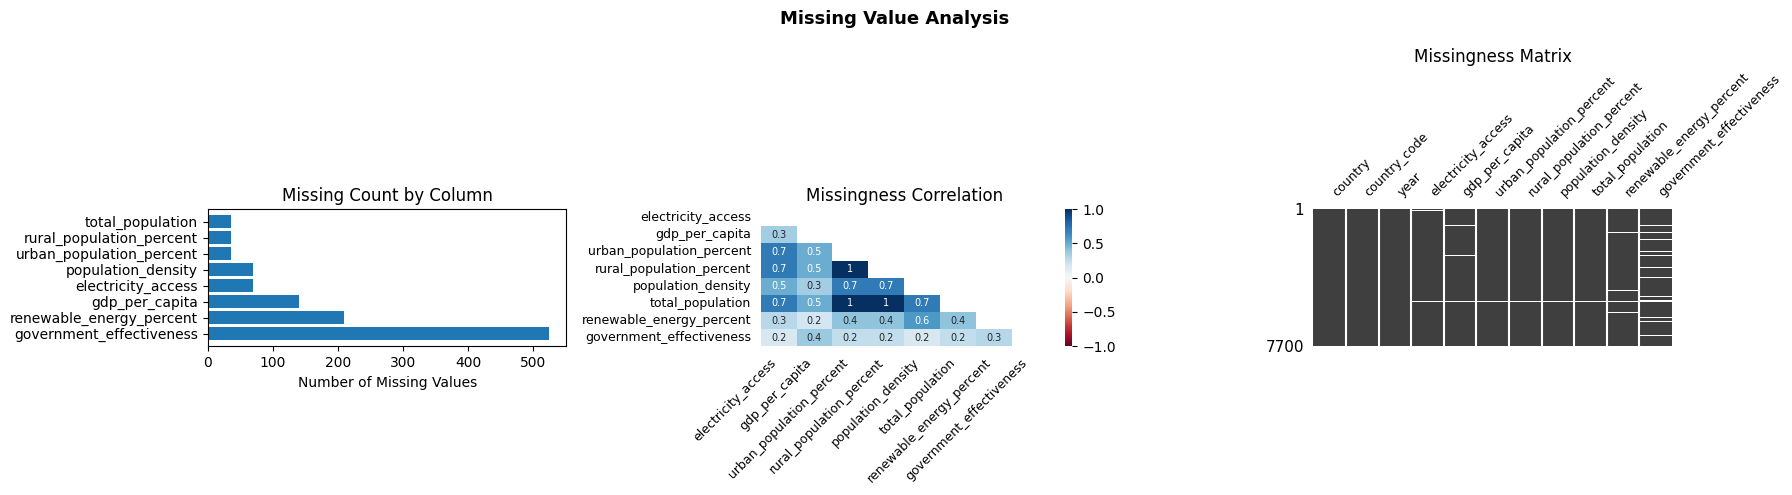

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Missing Value Analysis", fontsize=13, fontweight='bold')

# 1. Bar chart
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
axes[0].barh(missing_data.index, missing_data.values)
axes[0].set_xlabel('Number of Missing Values')
axes[0].set_title('Missing Count by Column')

# 2. Heatmap
msno.heatmap(df, ax=axes[1], fontsize=9)
axes[1].set_title("Missingness Correlation")

# 3. Matrix
msno.matrix(df, ax=axes[2], fontsize=9)
axes[2].set_title("Missingness Matrix")

plt.tight_layout()
plt.show()

In [18]:
# Create a copy for cleaning
df_clean = df.copy()

# Sort by country and year for proper time-series handling
df_clean = df_clean.sort_values(['country', 'year']).reset_index(drop=True)

print("Data sorted by country and year")
print(f"Shape: {df_clean.shape}")

Data sorted by country and year
Shape: (7700, 11)


In [19]:
# If any missing values remain in target variable, drop those rows
initial_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['electricity_access'])
final_rows = len(df_clean)

print(f"Rows before dropping missing targets: {initial_rows}")
print(f"Rows after dropping missing targets: {final_rows}")
print(f"Rows dropped: {initial_rows - final_rows}")

Rows before dropping missing targets: 7700
Rows after dropping missing targets: 7630
Rows dropped: 70


In [20]:
# Basic info
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7630 entries, 0 to 7699
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   7630 non-null   str    
 1   country_code              7630 non-null   str    
 2   year                      7630 non-null   int64  
 3   electricity_access        7630 non-null   float64
 4   gdp_per_capita            7525 non-null   float64
 5   urban_population_percent  7630 non-null   float64
 6   rural_population_percent  7630 non-null   float64
 7   population_density        7595 non-null   float64
 8   total_population          7630 non-null   float64
 9   renewable_energy_percent  7455 non-null   float64
 10  government_effectiveness  7140 non-null   float64
dtypes: float64(8), int64(1), str(2)
memory usage: 715.3 KB


# Feature Engineering

In [21]:
def create_risk_category(electricity_access):
    """
    Classify countries into risk categories based on electricity access percentage
    """
    if pd.isna(electricity_access):
        return None
    elif electricity_access < 50:
        return 'Severe'
    elif electricity_access < 90:
        return 'Moderate'
    else:
        return 'Minimal'

# Apply function to create target variable
df_clean['risk_category'] = df_clean['electricity_access'].apply(create_risk_category)

# Check distribution
print("Risk Category Distribution:")
print(df_clean['risk_category'].value_counts())
print("\nPercentages:")
print(df_clean['risk_category'].value_counts(normalize=True).mul(100).round(2))

Risk Category Distribution:
risk_category
Minimal     4774
Severe      1549
Moderate    1307
Name: count, dtype: int64

Percentages:
risk_category
Minimal     62.57
Severe      20.30
Moderate    17.13
Name: proportion, dtype: float64


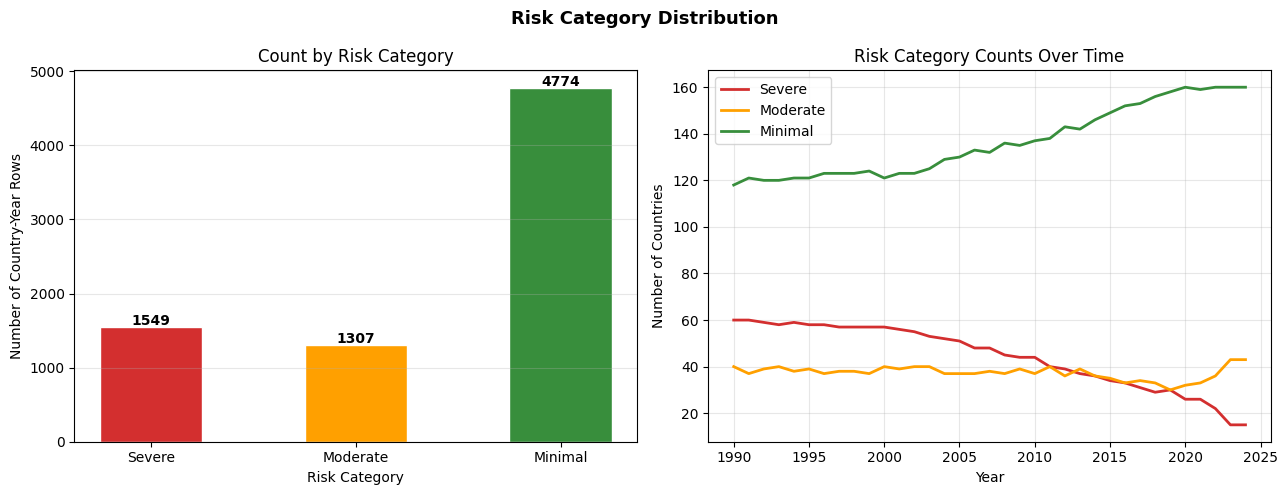

In [22]:
# Get value counts
counts = df_clean['risk_category'].value_counts()

# Visualize risk category distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Risk Category Distribution", fontsize=13, fontweight='bold')

order  = ['Severe', 'Moderate', 'Minimal']
colors = ['#D32F2F', '#FFA000', '#388E3C']
vals   = [counts.get(c, 0) for c in order]

# Bar chart
axes[0].bar(order, vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_xlabel("Risk Category")
axes[0].set_ylabel("Number of Country-Year Rows")
axes[0].set_title("Count by Risk Category")
for i, v in enumerate(vals):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# Risk mix over time
risk_by_year = (df_clean.groupby(['year', 'risk_category'])
                .size().unstack(fill_value=0))
for cat, col in zip(order, colors):
    if cat in risk_by_year.columns:
        axes[1].plot(risk_by_year.index, risk_by_year[cat],
                     label=cat, color=col, linewidth=2)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Countries")
axes[1].set_title("Risk Category Counts Over Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Year-over-year change in electricity access
df_clean['elec_access_change'] = df_clean.groupby('country_code')['electricity_access'].diff()

# GDP growth rate (percentage change)
df_clean['gdp_growth'] = df_clean.groupby('country_code')['gdp_per_capita'].pct_change() * 100

# Urbanization rate (year-over-year change in percentage points)
df_clean['urban_change'] = df_clean.groupby('country_code')['urban_population_percent'].diff()

print("Year-over-year change features created")
print("\nSample of new features:")
print(df_clean[['country', 'year', 'elec_access_change', 'gdp_growth', 'urban_change']].head(15))

Year-over-year change features created

Sample of new features:
        country  year  elec_access_change  gdp_growth  urban_change
0   Afghanistan  1990                 NaN         NaN           NaN
1   Afghanistan  1991                 0.0    0.000000      0.112626
2   Afghanistan  1992                 0.0    0.000000      0.111542
3   Afghanistan  1993                 0.0    0.000000      0.112265
4   Afghanistan  1994                 0.0    0.000000      0.114792
5   Afghanistan  1995                 0.0    0.000000      0.119125
6   Afghanistan  1996                 0.0    0.000000      0.125264
7   Afghanistan  1997                 0.0    0.000000      0.133208
8   Afghanistan  1998                 0.0    0.000000      0.142957
9   Afghanistan  1999                 0.0    0.000000      0.154512
10  Afghanistan  2000                 0.0    0.000000      0.167873
11  Afghanistan  2001                 4.9  -20.707691      0.183039
12  Afghanistan  2002                 4.8   29.01606

In [24]:
# Check for infinite values from pct_change
print("Checking for infinite values:")
print(f"GDP growth infinite values: {np.isinf(df_clean['gdp_growth']).sum()}")
print(f"Elec access change infinite values: {np.isinf(df_clean['elec_access_change']).sum()}")
print(f"Urban change infinite values: {np.isinf(df_clean['urban_change']).sum()}")

# Replace infinite values with NaN
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

print("\nInfinite values replaced with NaN")

Checking for infinite values:
GDP growth infinite values: 0
Elec access change infinite values: 0
Urban change infinite values: 0

Infinite values replaced with NaN


In [25]:
# Create lagged electricity access (previous year's value)
df_clean['lagged_electricity'] = df_clean.groupby('country_code')['electricity_access'].shift(1)

# Create lagged GDP per capita
df_clean['lagged_gdp'] = df_clean.groupby('country_code')['gdp_per_capita'].shift(1)

print("Lagged features created")
print("\nSample of lagged features:")
print(df_clean[['country', 'year', 'electricity_access', 'lagged_electricity', 'gdp_per_capita', 'lagged_gdp']].head(20))

Lagged features created

Sample of lagged features:
        country  year  electricity_access  lagged_electricity  gdp_per_capita  \
0   Afghanistan  1990                 4.4                 NaN      174.930991   
1   Afghanistan  1991                 4.4                 4.4      174.930991   
2   Afghanistan  1992                 4.4                 4.4      174.930991   
3   Afghanistan  1993                 4.4                 4.4      174.930991   
4   Afghanistan  1994                 4.4                 4.4      174.930991   
5   Afghanistan  1995                 4.4                 4.4      174.930991   
6   Afghanistan  1996                 4.4                 4.4      174.930991   
7   Afghanistan  1997                 4.4                 4.4      174.930991   
8   Afghanistan  1998                 4.4                 4.4      174.930991   
9   Afghanistan  1999                 4.4                 4.4      174.930991   
10  Afghanistan  2000                 4.4                

In [26]:
# Display all columns
print("All columns in dataset:")
print(df_clean.columns.tolist())
print(f"\nTotal columns: {len(df_clean.columns)}")
print(f"Dataset shape: {df_clean.shape}")

All columns in dataset:
['country', 'country_code', 'year', 'electricity_access', 'gdp_per_capita', 'urban_population_percent', 'rural_population_percent', 'population_density', 'total_population', 'renewable_energy_percent', 'government_effectiveness', 'risk_category', 'elec_access_change', 'gdp_growth', 'urban_change', 'lagged_electricity', 'lagged_gdp']

Total columns: 17
Dataset shape: (7630, 17)


In [27]:
# Check missing values in new features
print("Missing values in engineered features:")
engineered_features = ['risk_category', 'elec_access_change', 'gdp_growth', 'urban_change', 'lagged_electricity', 'lagged_gdp']
for col in engineered_features:
    missing = df_clean[col].isnull().sum()
    missing_pct = (missing / len(df_clean)) * 100
    print(f"{col}: {missing} ({missing_pct:.2f}%)")

Missing values in engineered features:
risk_category: 0 (0.00%)
elec_access_change: 218 (2.86%)
gdp_growth: 320 (4.19%)
urban_change: 218 (2.86%)
lagged_electricity: 218 (2.86%)
lagged_gdp: 320 (4.19%)


# Data Quality Checks

In [28]:
# Key Variables for Analysis and Outlier Detection
key_vars = [
    'electricity_access',
    'gdp_per_capita',
    'urban_population_percent',
    'rural_population_percent',
    'population_density',
    'total_population',
    'renewable_energy_percent',
    'government_effectiveness',
    'elec_access_change',
    'gdp_growth',
    'urban_change',
    'lagged_electricity',
    'lagged_gdp'
]

print("=" * 65)
print(f"{'Variable':<35} {'Outliers':>8} {'% of rows':>10}")
print("=" * 65)

outlier_summary = {}
for col in key_vars:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct   = n_out / len(df_clean) * 100
    outlier_summary[col] = {
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'n_outliers':  n_out
    }
    print(f"  {col:<33} {n_out:>8,} {pct:>9.1f}%")

print("=" * 65)
print("\nNote: Outliers are flagged, NOT removed.")
print("Many are legitimate (e.g. Qatar GDP, island microstates).")

Variable                            Outliers  % of rows
  electricity_access                     270       3.5%
  gdp_per_capita                         633       8.3%
  urban_population_percent                 0       0.0%
  rural_population_percent                 0       0.0%
  population_density                     740       9.7%
  total_population                       947      12.4%
  renewable_energy_percent                 0       0.0%
  government_effectiveness                 0       0.0%
  elec_access_change                   1,387      18.2%
  gdp_growth                             540       7.1%
  urban_change                           395       5.2%
  lagged_electricity                     189       2.5%
  lagged_gdp                             609       8.0%

Note: Outliers are flagged, NOT removed.
Many are legitimate (e.g. Qatar GDP, island microstates).


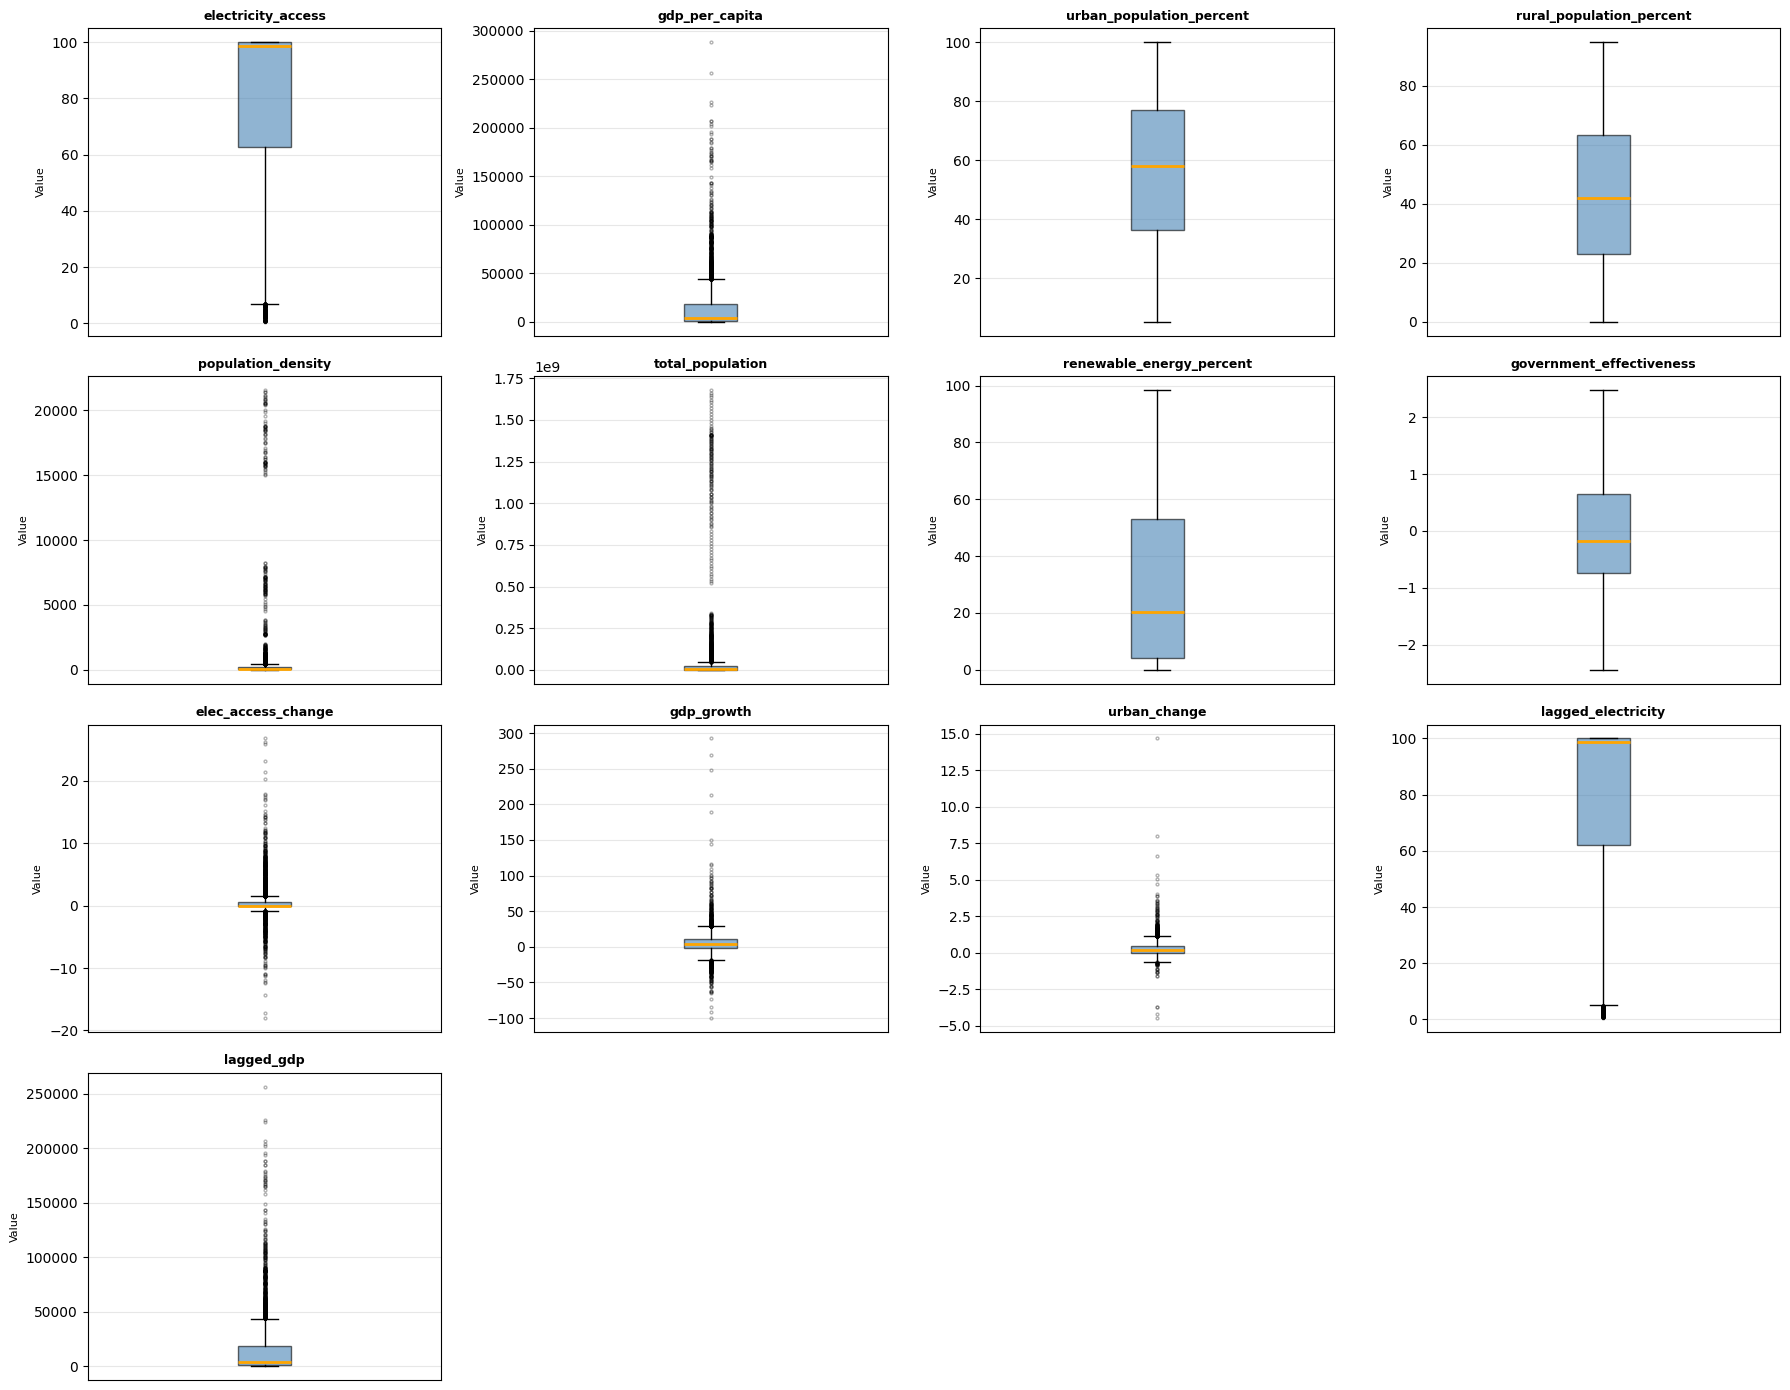

In [29]:
# Box Plots for All Variables to visialize outliers 

ffig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("Box Plots — Outlier Detection Across All Variables",
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(key_vars):
    data = df_clean[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='orange', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel("Value", fontsize=8)
    axes[i].set_xticks([])         
    axes[i].grid(True, alpha=0.3)

for j in range(len(key_vars), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
# Top Extreme Outlier Examples

print("=== Top 3 Extreme Outliers Per Variable ===\n")

for col in key_vars:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    top = (df_clean[df_clean[col] > upper]
           .nlargest(3, col)[['country', 'year', col]])
    bot = (df_clean[df_clean[col] < lower]
           .nsmallest(3, col)[['country', 'year', col]])

    if len(top) > 0 or len(bot) > 0:
        print(f"── {col} ──")
        if len(top) > 0:
            print("  High outliers:")
            print(top.to_string(index=False))
        if len(bot) > 0:
            print("  Low outliers:")
            print(bot.to_string(index=False))
        print()

=== Top 3 Extreme Outliers Per Variable ===

── electricity_access ──
  Low outliers:
    country  year  electricity_access
     Uganda  1994            0.533899
South Sudan  1990            0.800000
South Sudan  1991            0.800000

── gdp_per_capita ──
  High outliers:
country  year  gdp_per_capita
 Monaco  2024   288001.433369
 Monaco  2023   256799.788613
 Monaco  2022   226052.001905

── population_density ──
  High outliers:
         country  year  population_density
Macao SAR, China  2000        21530.000000
Macao SAR, China  2016        21393.442623
Macao SAR, China  1999        21370.000000

── total_population ──
  High outliers:
                country  year  total_population
South Asia (IDA & IBRD)  2024      1677384532.0
South Asia (IDA & IBRD)  2023      1662580579.0
South Asia (IDA & IBRD)  2022      1648009565.0

── elec_access_change ──
  High outliers:
           country  year  elec_access_change
Somalia, Fed. Rep.  2010                26.8
       Afghanistan  20

In [31]:
print("=== Outlier Summary (sorted by count) ===\n")

summary_df = pd.DataFrame(outlier_summary).T
summary_df = summary_df.sort_values('n_outliers', ascending=False)
summary_df['pct'] = (summary_df['n_outliers'] / len(df_clean) * 100).round(1)

print(summary_df[['n_outliers', 'pct', 'lower_bound', 'upper_bound']].to_string())
print(f"\nTotal outlier flags: {summary_df['n_outliers'].sum():,}")
print("\nDecision: All outliers KEPT — they represent real-world variation")

=== Outlier Summary (sorted by count) ===

                          n_outliers   pct  lower_bound  upper_bound
elec_access_change            1387.0  18.2        -0.90         1.50
total_population               947.0  12.4 -28602908.62  49588884.38
population_density             740.0   9.7      -228.56       464.67
gdp_per_capita                 633.0   8.3    -24593.48     44077.28
lagged_gdp                     609.0   8.0    -24387.65     43668.99
gdp_growth                     540.0   7.1       -18.82        28.82
urban_change                   395.0   5.2        -0.65         1.13
electricity_access             270.0   3.5         6.81       155.91
lagged_electricity             189.0   2.5         5.00       157.00
urban_population_percent         0.0   0.0       -24.34       137.98
rural_population_percent         0.0   0.0       -37.98       124.34
renewable_energy_percent         0.0   0.0       -69.50       126.50
government_effectiveness         0.0   0.0        -2.83     

In [32]:
# Verify risk_category Distribution

print("=== Risk Category Distribution ===\n")

counts = df_clean['risk_category'].value_counts()
pcts   = df_clean['risk_category'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': counts, 'percentage': pcts.round(1)})
print(summary)

# Verify boundaries match electricity_access values exactly
print("\n--- Boundary Verification ---")
severe_max   = df_clean[df_clean['risk_category'] == 'Severe']['electricity_access'].max()
moderate_min = df_clean[df_clean['risk_category'] == 'Moderate']['electricity_access'].min()
moderate_max = df_clean[df_clean['risk_category'] == 'Moderate']['electricity_access'].max()
minimal_min  = df_clean[df_clean['risk_category'] == 'Minimal']['electricity_access'].min()

print(f"Severe   max : {severe_max:.2f}   (should be < 50)")
print(f"Moderate min : {moderate_min:.2f}  (should be >= 50)")
print(f"Moderate max : {moderate_max:.2f}  (should be < 90)")
print(f"Minimal  min : {minimal_min:.2f}   (should be >= 90)")

# Check no row is uncategorised
n_null = df_clean['risk_category'].isna().sum()
print(f"\nRows with no risk_category: {n_null}  (should be 0)")

=== Risk Category Distribution ===

               count  percentage
risk_category                   
Minimal         4774        62.6
Severe          1549        20.3
Moderate        1307        17.1

--- Boundary Verification ---
Severe   max : 49.90   (should be < 50)
Moderate min : 50.00  (should be >= 50)
Moderate max : 90.00  (should be < 90)
Minimal  min : 90.00   (should be >= 90)

Rows with no risk_category: 0  (should be 0)


In [33]:
# Data Leakage check — ensure no future data is used in features

print("=== Data Leakage Check ===\n")

# Verify lagged_electricity equals electricity_access from prior year
df_sorted = df_clean.sort_values(['country', 'year']).copy()
df_sorted['expected_lag1'] = df_sorted.groupby('country')['electricity_access'].shift(1)

# Only check rows where a prior year exists
has_prior = df_sorted['expected_lag1'].notna()
mismatch  = (
    (df_sorted.loc[has_prior, 'lagged_electricity'] -
     df_sorted.loc[has_prior, 'expected_lag1']).abs() > 0.001
).sum()
print(f"lagged_electricity mismatch: {mismatch}  (should be 0)")

# Verify lagged_gdp equals gdp_per_capita from prior year
df_sorted['expected_gdp_lag1'] = df_sorted.groupby('country')['gdp_per_capita'].shift(1)
has_prior_gdp = df_sorted['expected_gdp_lag1'].notna()
gdp_mismatch  = (
    (df_sorted.loc[has_prior_gdp, 'lagged_gdp'] -
     df_sorted.loc[has_prior_gdp, 'expected_gdp_lag1']).abs() > 0.001
).sum()
print(f"lagged_gdp mismatch:         {gdp_mismatch}  (should be 0)")

# Verify elec_access_change uses past not future
df_sorted['expected_change'] = (
    df_sorted['electricity_access'] - df_sorted['expected_lag1']
)
change_mismatch = (
    (df_sorted.loc[has_prior, 'elec_access_change'] -
     df_sorted.loc[has_prior, 'expected_change']).abs() > 0.001
).sum()
print(f"elec_access_change mismatch: {change_mismatch}  (should be 0)")

# Manual check on one country
print("\n--- Manual verification for India ---")
india = df_sorted[df_sorted['country'] == 'India'][
    ['country', 'year', 'electricity_access', 'lagged_electricity', 'elec_access_change']
].head(8)
print(india.to_string(index=False))

print("\nNo data leakage detected." if mismatch == 0 and gdp_mismatch == 0 and change_mismatch == 0
      else "\nLeakage detected — review lag construction.")

=== Data Leakage Check ===

lagged_electricity mismatch: 0  (should be 0)
lagged_gdp mismatch:         0  (should be 0)
elec_access_change mismatch: 0  (should be 0)

--- Manual verification for India ---
country  year  electricity_access  lagged_electricity  elec_access_change
  India  1990           50.900000                 NaN                 NaN
  India  1991           50.900000           50.900000            0.000000
  India  1992           50.900000           50.900000            0.000000
  India  1993           50.900000           50.900000            0.000000
  India  1994           49.811310           50.900000           -1.088690
  India  1995           51.408775           49.811310            1.597466
  India  1996           53.003521           51.408775            1.594746
  India  1997           54.594864           53.003521            1.591343

No data leakage detected.


In [34]:
# Verify Year Range

print("=== Year Range Verification ===\n")

min_year = int(df_clean['year'].min())
max_year = int(df_clean['year'].max())
all_years     = set(range(1990, 2024))
present_years = set(df_clean['year'].unique().astype(int))
missing_years = all_years - present_years

print(f"Min year : {min_year}  (expected 1990)")
print(f"Max year : {max_year}  (expected 2023)")
print(f"Missing years : {sorted(missing_years) if missing_years else 'None'}")

# Rows outside valid window
outside = df_clean[(df_clean['year'] < 1990) | (df_clean['year'] > 2023)]
print(f"Rows outside 1990–2023 : {len(outside)}  (should be 0)")

# Countries per year
country_by_year = df_clean.groupby('year')['country'].nunique()
print(f"\nCountries per year — min: {country_by_year.min()}  max: {country_by_year.max()}")
print("\nFirst 5 years:")
print(country_by_year.head().to_string())
print("\nLast 5 years:")
print(country_by_year.tail().to_string())

=== Year Range Verification ===

Min year : 1990  (expected 1990)
Max year : 2024  (expected 2023)
Missing years : None
Rows outside 1990–2023 : 218  (should be 0)

Countries per year — min: 218  max: 218

First 5 years:
year
1990    218
1991    218
1992    218
1993    218
1994    218

Last 5 years:
year
2020    218
2021    218
2022    218
2023    218
2024    218


In [35]:
# FIX: drop 2024 
if len(outside) > 0:
    df_clean = df_clean[df_clean['year'] <= 2023].reset_index(drop=True)
    print(f"\nDropped {len(outside)} rows from 2024. New shape: {df_clean.shape}")

country_by_year = df_clean.groupby('year')['country'].nunique()
print(f"\nCountries per year — min: {country_by_year.min()}  max: {country_by_year.max()}")
print("\nFirst 5 years:")
print(country_by_year.head().to_string())
print("\nLast 5 years:")
print(country_by_year.tail().to_string())


Dropped 218 rows from 2024. New shape: (7412, 17)

Countries per year — min: 218  max: 218

First 5 years:
year
1990    218
1991    218
1992    218
1993    218
1994    218

Last 5 years:
year
2019    218
2020    218
2021    218
2022    218
2023    218


In [36]:
# Impossible Values Check   

print("=== Impossible Value Check ===\n")

checks = {
    'electricity_access':       (0,   100,  "must be 0–100%"),
    'urban_population_percent': (0,   100,  "must be 0–100%"),
    'rural_population_percent': (0,   100,  "must be 0–100%"),
    'renewable_energy_percent': (0,   100,  "must be 0–100%"),
    'gdp_per_capita':           (0,   None, "must be non-negative"),
    'population_density':       (0,   None, "must be non-negative"),
    'total_population':         (0,   None, "must be non-negative"),
    'lagged_electricity':       (0,   100,  "must be 0–100% same as source"),
    'lagged_gdp':               (0,   None, "must be non-negative same as source"),
}

all_ok = True
print(f"{'Column':<35} {'Violations':>10}  Rule")
print("-" * 70)

for col, (lo, hi, rule) in checks.items():
    mask = pd.Series([False] * len(df_clean), index=df_clean.index)
    if lo is not None:
        mask = mask | (df_clean[col] < lo)
    if hi is not None:
        mask = mask | (df_clean[col] > hi)
    n = mask.sum()
    if n > 0:
        all_ok = False
    status = "OK" if n == 0 else f"⚠  {n} rows"
    print(f"  {col:<33} {n:>10}  {rule}  →  {status}")

print("-" * 70)

# Urban + rural should sum to ~100
df_clean['_urban_rural_sum'] = (
    df_clean['urban_population_percent'] + df_clean['rural_population_percent']
)
bad_sum = ((df_clean['_urban_rural_sum'] - 100).abs() > 1).sum()
df_clean.drop(columns=['_urban_rural_sum'], inplace=True)
print(f"\n  urban% + rural% deviates > 1pp : {bad_sum} rows  (should be 0)")

# risk_category consistent with electricity_access
cat_mismatch = (
    ((df_clean['risk_category'] == 'Severe')   & (df_clean['electricity_access'] >= 50)) |
    ((df_clean['risk_category'] == 'Moderate') & ((df_clean['electricity_access'] < 50) | (df_clean['electricity_access'] >= 90))) |
    ((df_clean['risk_category'] == 'Minimal')  & (df_clean['electricity_access'] < 90))
).sum()
print(f"  risk_category mismatches       : {cat_mismatch} rows  (should be 0)")

print("\n" + ("All checks passed." if all_ok and bad_sum == 0 and cat_mismatch == 0
              else "Some issues found — review above."))

=== Impossible Value Check ===

Column                              Violations  Rule
----------------------------------------------------------------------
  electricity_access                         0  must be 0–100%  →  OK
  urban_population_percent                   0  must be 0–100%  →  OK
  rural_population_percent                   0  must be 0–100%  →  OK
  renewable_energy_percent                   0  must be 0–100%  →  OK
  gdp_per_capita                             0  must be non-negative  →  OK
  population_density                         0  must be non-negative  →  OK
  total_population                           0  must be non-negative  →  OK
  lagged_electricity                         0  must be 0–100% same as source  →  OK
  lagged_gdp                                 0  must be non-negative same as source  →  OK
----------------------------------------------------------------------

  urban% + rural% deviates > 1pp : 0 rows  (should be 0)
  risk_category mismatches     

In [37]:
#  FIX: handle remaining NaNs 
remaining_nans = df_clean.isnull().sum().sum()
if remaining_nans > 0:
    print(f"\nFound {remaining_nans} remaining NaNs — fixing now...")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    cols_with_nan = df_clean.columns[df_clean.isnull().any()].tolist()
    df_clean = df_clean.sort_values(['country', 'year']).reset_index(drop=True)

    for col in cols_with_nan:
        df_clean[col] = (
            df_clean.groupby('country')[col]
            .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
        )
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    print(f"Remaining NaNs after fix: {df_clean.isnull().sum().sum()}")
else:
    print("\nNo NaNs found.")


Found 2070 remaining NaNs — fixing now...
gdp_per_capita              102
population_density           34
renewable_energy_percent    170
government_effectiveness    476
elec_access_change          218
gdp_growth                  317
urban_change                218
lagged_electricity          218
lagged_gdp                  317
dtype: int64
Remaining NaNs after fix: 0


In [38]:
# Final Quality Report

print("=" * 55)
print("      DATA QUALITY REPORT — FINAL SUMMARY")
print("=" * 55)
print(f"  Total rows             : {len(df_clean):,}")
print(f"  Total columns          : {len(df_clean.columns)}")
print(f"  Unique countries       : {df_clean['country'].nunique()}")
print(f"  Year range             : {int(df_clean['year'].min())}–{int(df_clean['year'].max())}")
print(f"  Remaining NaNs         : {df_clean.isnull().sum().sum()}")
print(f"  Duplicate rows         : {df_clean.duplicated().sum()}")
print(f"  Risk categories        : {sorted(df_clean['risk_category'].unique().tolist())}")
print("=" * 55)
print("\nOutlier decisions:")
print("  - elec_access_change  18.2% — expected for delta column, kept")
print("  - total_population    12.4% — China/India structural, kept")
print("  - population_density   9.7% — city-states structural, kept")
print("  - gdp_per_capita       8.3% — oil-rich states real values, kept")
print("  - All others           <8%  — real-world variation, kept")
print("\nDataset is clean and ready for modeling.")

      DATA QUALITY REPORT — FINAL SUMMARY
  Total rows             : 7,412
  Total columns          : 17
  Unique countries       : 218
  Year range             : 1990–2023
  Remaining NaNs         : 0
  Duplicate rows         : 0
  Risk categories        : ['Minimal', 'Moderate', 'Severe']

Outlier decisions:
  - elec_access_change  18.2% — expected for delta column, kept
  - total_population    12.4% — China/India structural, kept
  - population_density   9.7% — city-states structural, kept
  - gdp_per_capita       8.3% — oil-rich states real values, kept
  - All others           <8%  — real-world variation, kept

Dataset is clean and ready for modeling.


In [39]:

os.makedirs("data/processed", exist_ok=True)

df_clean.to_csv("data/processed/analysis_ready.csv", index=False)

print("Saved: data/processed/analysis_ready.csv")
print(f"  Shape    : {df_clean.shape}")
print(f"  Rows     : {len(df_clean):,}")
print(f"  Columns  : {len(df_clean.columns)}")
print(f"  Year range: {int(df_clean['year'].min())}–{int(df_clean['year'].max())}")
print(f"  Countries : {df_clean['country'].nunique()}")


Saved: data/processed/analysis_ready.csv
  Shape    : (7412, 17)
  Rows     : 7,412
  Columns  : 17
  Year range: 1990–2023
  Countries : 218
